In [1]:
import os
import pandas as pd 
import random
from sklearn.model_selection import train_test_split
import tensorflow as tf 
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.callbacks import LearningRateScheduler
from tensorflow.keras import datasets, layers, models, callbacks
from tensorflow.keras.models import load_model
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img, img_to_array

In [2]:
# Paths to the dataset files
data_dir = os.path.expanduser("~/Desktop/iitk_dl")
csv_path = os.path.join(data_dir, "driver_imgs_list.csv")
img_dir = os.path.join(data_dir, "imgs/train")


In [3]:
data=pd.read_csv(csv_path)


In [4]:
print(data.head())
print(data.columns.tolist())

  subject classname            img
0    p002        c0  img_44733.jpg
1    p002        c0  img_72999.jpg
2    p002        c0  img_25094.jpg
3    p002        c0  img_69092.jpg
4    p002        c0  img_92629.jpg
['subject', 'classname', 'img']


In [5]:
data['path'] = data.apply(lambda row: os.path.join(img_dir, row['classname'], row['img']), axis=1)


In [6]:
train_data , val_data = train_test_split(data , test_size=0.3 , stratify=data['classname'], random_state=42)
print(train_data['classname'].value_counts())
print(val_data['classname'].value_counts())

classname
c0    1742
c3    1642
c4    1628
c6    1628
c2    1622
c5    1618
c1    1587
c9    1490
c7    1401
c8    1338
Name: count, dtype: int64
classname
c0    747
c3    704
c4    698
c6    697
c2    695
c5    694
c1    680
c9    639
c7    601
c8    573
Name: count, dtype: int64


In [7]:
IMG_SIZE = (224,224)
BATCH_SIZE = 32

datagen = ImageDataGenerator(
    rescale=1.0/255.0,
    validation_split=0.2,  # Ensure split consistency
    rotation_range=15,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1.0/255.0)

train_generator = datagen.flow_from_dataframe(
    dataframe=train_data,
    directory=img_dir,
    x_col='path',
    y_col='classname',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_generator = datagen.flow_from_dataframe(
    dataframe=val_data,
    directory=img_dir,
    x_col='path',
    y_col='classname',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

Found 15696 validated image filenames belonging to 10 classes.
Found 6728 validated image filenames belonging to 10 classes.


In [8]:
def create_cnn_model(input_shape=(240, 240, 3), num_classes=10):
    model = Sequential()

    # First Convolutional Block
    model.add(Conv2D(32, (3, 3), activation='relu', input_shape=input_shape))
    model.add(BatchNormalization())
    model.add(Conv2D(32,(3,3),activation='relu',padding='same'))
    model.add(BatchNormalization(axis = 3))
    model.add(MaxPooling2D(pool_size=(2,2),padding='same'))
    model.add(Dropout(0.3))

    # Second Convolutional Block
    model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(Conv2D(64,(3,3),activation='relu',padding='same'))
    model.add(BatchNormalization(axis = 3))
    model.add(MaxPooling2D(pool_size=(2,2),padding='same'))
    model.add(Dropout(0.3))

    # Third Convolutional Block
    model.add(Conv2D(128, (3, 3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(Conv2D(128,(3,3),activation='relu',padding='same'))
    model.add(BatchNormalization(axis = 3))
    model.add(MaxPooling2D(pool_size=(2,2),padding='same'))
    model.add(Dropout(0.5))

    # Flatten and Fully Connected Layers
    model.add(Flatten())
    model.add(Dense(units = 512,activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.5))
    model.add(Dense(units = 128,activation='relu'))
    model.add(Dropout(0.25))
    model.add(Dense(10,activation='softmax'))

    return model

# Create the CNN model
cnn_model = create_cnn_model(input_shape=(224, 224, 3), num_classes=10)
cnn_model.summary()



/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2024-12-11 21:12:10.251089: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Pro
2024-12-11 21:12:10.251123: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 24.00 GB
2024-12-11 21:12:10.251129: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 8.00 GB
2024-12-11 21:12:10.251159: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2024-12-11 21:12:10.251175: I tensorflow/core/common_runtime/pluggable_devic

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 222, 222, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 111, 111, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 111, 111, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 111, 111, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 111, 111, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    51,380,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 51,738,538 (197.37 MB)

 Trainable params: 51,736,618 (197.36 MB)

 Non-trainable params: 1,920 (7.50 KB)

In [9]:
cnn_model.compile(
    loss='categorical_crossentropy',
    metrics=['accuracy'],
    optimizer='adam'
)
callback = [callbacks.EarlyStopping(monitor='val_accuracy',patience=5)]
batch_size = 70
n_epochs = 10

In [10]:
# Define the ModelCheckpoint callback to save the best model based on validation accuracy
checkpoint = ModelCheckpoint(
    'cnn_distracted_driver_best_model.keras',  # Path to save the best model
    monitor='val_accuracy',  # Metric to monitor
    save_best_only=True,  # Save the best model only
    verbose=1  # Print a message when saving the model
)

# Define the EarlyStopping callback to stop training if validation loss doesn't improve
early_stopping = EarlyStopping(
    monitor='val_loss',  # Monitor validation loss
    patience=5,  # Number of epochs with no improvement before stopping
    verbose=1  # Print a message when stopping training
)

history = cnn_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    callbacks=[checkpoint, early_stopping]
)



/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10


2024-12-11 21:12:12.543345: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


491/491 ━━━━━━━━━━━━━━━━━━━━ 0s 242ms/step - accuracy: 0.1172 - loss: 3.7016
Epoch 1: val_accuracy improved from -inf to 0.11519, saving model to cnn_distracted_driver_best_model.keras
491/491 ━━━━━━━━━━━━━━━━━━━━ 147s 295ms/step - accuracy: 0.1173 - loss: 3.7006 - val_accuracy: 0.1152 - val_loss: 2.7946
Epoch 2/10
491/491 ━━━━━━━━━━━━━━━━━━━━ 0s 245ms/step - accuracy: 0.1681 - loss: 2.5291
Epoch 2: val_accuracy did not improve from 0.11519
491/491 ━━━━━━━━━━━━━━━━━━━━ 145s 295ms/step - accuracy: 0.1681 - loss: 2.5288 - val_accuracy: 0.1037 - val_loss: 7.7247
Epoch 3/10
491/491 ━━━━━━━━━━━━━━━━━━━━ 0s 240ms/step - accuracy: 0.2380 - loss: 2.1287
Epoch 3: val_accuracy improved from 0.11519 to 0.23841, saving model to cnn_distracted_driver_best_model.keras
491/491 ━━━━━━━━━━━━━━━━━━━━ 142s 289ms/step - accuracy: 0.2380 - loss: 2.1286 - val_accuracy: 0.2384 - val_loss: 2.0655
Epoch 4/10
491/491 ━━━━━━━━━━━━━━━━━━━━ 0s 240ms/step - accuracy: 0.3181 - loss: 1.8744
Epoch 4: val_accuracy impr

In [12]:
# Evaluate model
val_loss, val_accuracy = cnn_model.evaluate(val_generator)
print(f"Validation Accuracy: {val_accuracy * 100:.2f}%")

# Save model
cnn_model.save("distracted_driver_model.keras")


211/211 ━━━━━━━━━━━━━━━━━━━━ 24s 112ms/step - accuracy: 0.5965 - loss: 1.1959
Validation Accuracy: 58.84%


In [13]:
model = load_model("distracted_driver_model.keras")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step


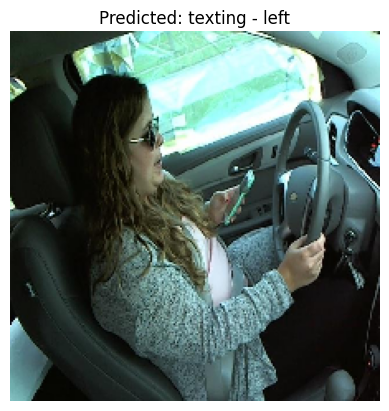

The model predicts: texting - left


In [14]:
class_labels = [
    "safe driving", 
    "texting - right", 
    "talking on the phone - right", 
    "texting - left", 
    "talking on the phone - left", 
    "operating the radio", 
    "drinking", 
    "reaching behind", 
    "hair and makeup", 
    "talking to passenger"
]

def predict_random_image(model, img_dir):
    # Get a list of all images in the directory
    img_classes = os.listdir(img_dir)  # Get all class directories in the dataset
    random_class = random.choice(img_classes)  # Pick a random class
    class_path = os.path.join(img_dir, random_class)  # Path to the random class folder
    
    # Get a random image from the selected class
    random_img_name = random.choice(os.listdir(class_path))  # Random image in that class
    img_path = os.path.join(class_path, random_img_name)  # Full image path
    
    # Load and preprocess the image
    img = load_img(img_path, target_size=(224, 224))  # Resize the image to (224, 224)
    img_array = img_to_array(img)  # Convert the image to a numpy array
    img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension (required for prediction)
    img_array = img_array / 255.0  # Normalize the image
    
    # Make the prediction
    predictions = model.predict(img_array)
    predicted_class_index = np.argmax(predictions)  # Get the index of the highest probability
    
    # Get the predicted class label
    predicted_class = class_labels[predicted_class_index]
    
    # Display the image and prediction
    plt.imshow(img)
    plt.title(f"Predicted: {predicted_class}")
    plt.axis('off')
    plt.show()
    
    return predicted_class

# Example usage (assuming 'model' is your trained model)
predicted_class = predict_random_image(model, '/Users/sidharthrs/Desktop/iitk_dl/imgs/train')
print(f"The model predicts: {predicted_class}")
